In [50]:
import sys
import os

# Adicione o caminho da pasta raiz do projeto ao sys.path
project_path = '/media/renato/Data/Work/pucpr_pibic_semantic_segmentation/'
sys.path.append(os.path.abspath(project_path))

from dotenv import load_dotenv
from core.validation import get_valid_image_number
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


### Setup ###
# Load variables from .env file
load_dotenv()

# Base Path for image folder
base_mask_folder: str = os.getenv("BASE_MASK_V2_FOLDER")
output_folder: str = os.getenv("OUTPUT_FOLDER")

img_number: str = get_valid_image_number()
mask_path: str = os.path.join(base_mask_folder, f"{img_number}.png")

# Load and Convert Images
bgr_img = cv.imread(mask_path, 1)
hsv_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2HSV)


In [51]:
# Check shape
print(hsv_img.shape) # Result: (720, 1280, 3)

(720, 1280, 3)


In [64]:
# Get HSV color value
"""
OpenCV halves the H values to fit the range [0,255], so H value instead of being in range [0, 360], is in range [0, 180].
S and V are still in range [0, 255].
"""
import cv2 as cv
import numpy as np

# RGB => BGR (OpenCV)
# Walker Color: Hex(#64137f) => RGB [100, 19, 127] => HSV (286°, 85%, 50%)
walker_color = np.uint8([[[127, 19, 100]]])   #BGR (OpenCV)
hsv_color = cv.cvtColor(walker_color, cv.COLOR_BGR2HSV)
print(hsv_color) # Expected value: [143, 217, 127] (Hue, Saturation, Value)

[[[143 217 127]]]


In [61]:
# Inspect the actual color values ​​in the image for each pixel
# cv.imshow("Inspect Image", bgr_img)
cv.imshow("Inspect Image", hsv_img)
# cv.imshow("Inspect Mask", mask)
cv.waitKey(0)
cv.destroyAllWindows()

"""
Writing down values (Hue, Saturation, Value)
lower_bound = [142, 148, 20]
upper_bound = [145, 178, 255]
"""

'\nWriting down values (Hue, Saturation, Value)\nlower_bound = [142, 148, 20]\nupper_bound = [145, 178, 255]\n'

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

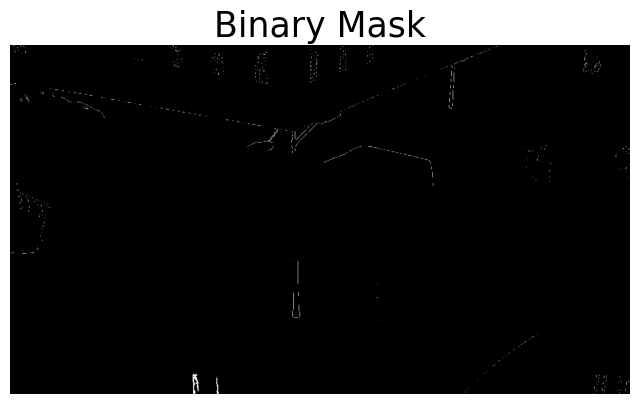

In [ ]:
### Process ###
# First Step - Limits
# 1 - Define Walker color limits >> HSV (H:6, S:23, V:225) to (H:9, S:42, V:235)
lower_bound = np.array([142, 148, 20]) # Hue, Saturation, Value
upper_bound = np.array([145, 178, 255]) # Hue, Saturation, Value

# Second Step - Binary Mask
# 2.1 - Create mask
mask = cv.inRange(hsv_img, lower_bound, upper_bound)

# 2.2 - Binarize
mask = np.where(mask > 0, 255, 0).astype(np.uint8)

# 2.3 - Visualize binary mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

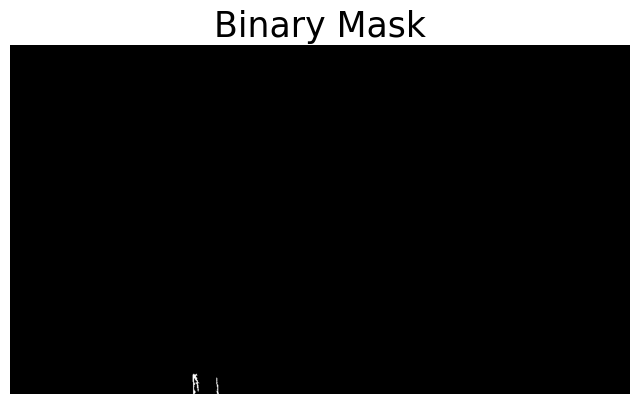

In [65]:
# Third Step - Remove Noise
# 3.1 - Find Contours
contours, hierarchy = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

# Create empty mask
filtered_mask = np.zeros_like(mask)

# Define minimum area
min_area = 3 # manual fine tuning

# 3.2 - Filter
for contour in contours:
    area = cv.contourArea(contour)
    if area >= min_area:
        cv.drawContours(filtered_mask, [contour], -1, (255), -1)

# 3.3 - Reassign mask with the filtered mask
mask = filtered_mask

# 3.4 - Visualize updated mask
plt.figure(figsize=[8,8])
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')


(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

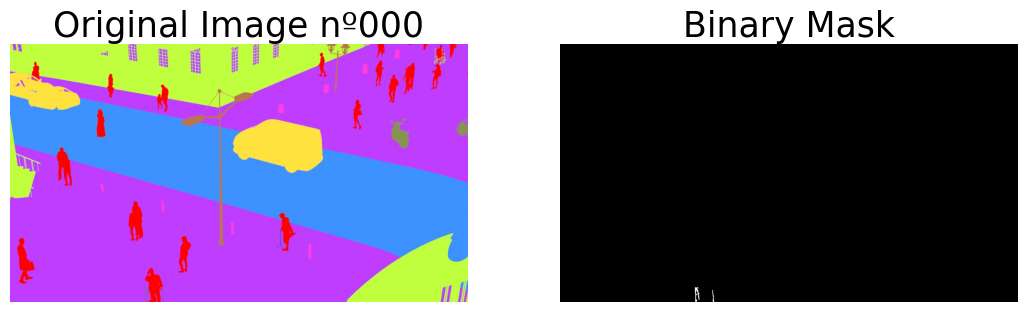

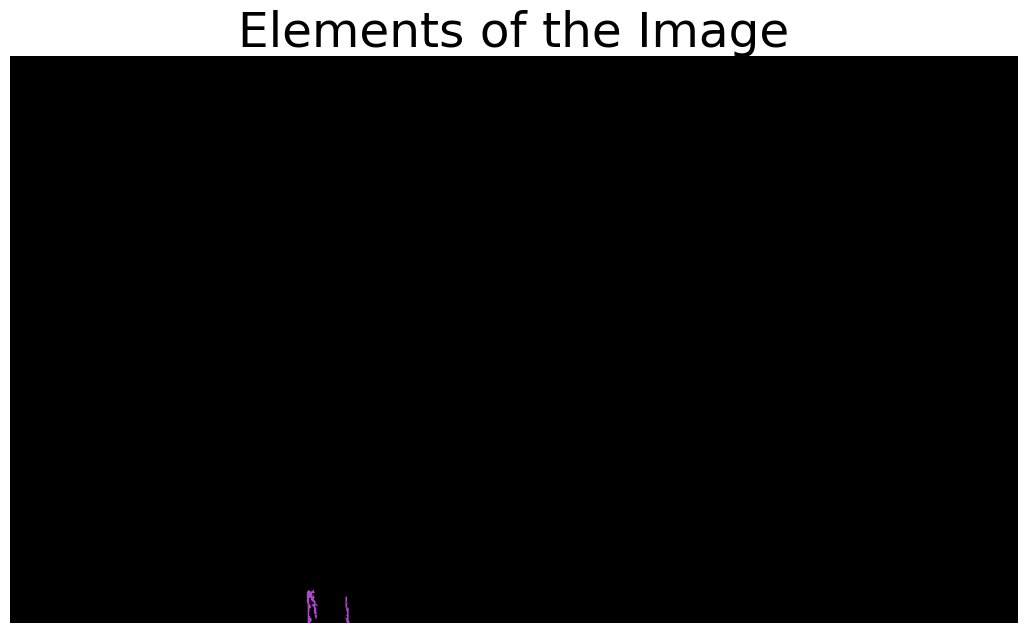

In [66]:
# Visualize Segmentation
# Setup Plot
plt.figure(figsize=[13,13])
# Plotting original image
plt.subplot(121)
plt.imshow(bgr_img[:,:,::-1])
plt.title(f"Original Image nº{img_number}",fontdict={'fontsize': 25})
plt.axis('off')
# Plotting binary mask
plt.subplot(122)
plt.imshow(mask, cmap='gray')
plt.title("Binary Mask",fontdict={'fontsize': 25})
plt.axis('off')

# Applying mask
result = cv.bitwise_and(bgr_img, bgr_img, mask=mask)

# Plotting result
plt.figure(figsize=[13,13])
plt.imshow(result[:,:,::-1])
plt.title("Elements of the Image",fontdict={'fontsize':35})
plt.axis('off')